# UEBA Synthetic Data Generation & Analysis
This notebook generates a multi-dimensional dataset for a User and Entity Behavior Analytics (UEBA) system. It simulates normal user behavior and injects realistic anomalies (hacks, bots, and data exfiltration) at a 3% attack rate.

## Data Dictionary
The data is split across three modules, simulating a microservice logging architecture:

| Log File | Features Generated | Purpose |
| :--- | :--- | :--- |
| **`log_login`** | `login_id`, `user_id`, `timestamp`, `country`, `city`, `user_agent`, `os`, `resolution`, `login_status`, `auth_method`, `is_anomaly` | Tracks authentication context. Acts as the master table containing the ground-truth `is_anomaly` label. |
| **`log_behavior`** | `login_id`, `user_id`, `mouse_velocity_px_sec`, `avg_keystroke_delay`, `session_entropy`, `tab_switch_count` | Captures in-session human-computer interaction (HCI) metrics to detect bot/script activity. |
| **`log_network`** | `login_id`, `user_id`, `bytes_sent`, `destination_port`, `protocol`, `packet_loss_rate` | Monitors backend traffic to detect scanning or data exfiltration. |

In [2]:
pip install faker pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.0 MB/s eta 0:00:00


Data synthesis

In [9]:
import pandas as pd
import numpy as np
import random
from faker import Faker
from datetime import datetime, timedelta
import os

fake = Faker()
Faker.seed(42)
np.random.seed(42)
random.seed(42)

# -----------------------------
# CONFIG
# -----------------------------
NUM_USERS = 500
ANOMALY_RATE = 0.08  # 8% anomalous sessions
os.makedirs("data", exist_ok=True)

# -----------------------------
# HELPER FUNCTIONS
# -----------------------------
def generate_user_profile(user_id):
    """
    Each user has their own consistent baseline.
    Any deviation = anomaly.
    """
    home_country = random.choices(
        ["India", "US", "Germany", "UK", "Singapore"],
        weights=[0.55, 0.15, 0.1, 0.1, 0.1]
    )[0]

    preferred_os = random.sample(["Windows", "Mac", "Linux"], k=random.choice([1, 2]))
    preferred_auth = random.choice(["Password", "MFA"])
    preferred_resolution = random.choice(["1920x1080", "1366x768", "2560x1440"])

    # Behavioral baselines
    mouse_velocity = np.random.normal(300, 40)
    keystroke_delay = np.random.normal(0.25, 0.05)
    entropy = np.random.normal(0.8, 0.05)
    tab_switch = np.random.normal(6, 2)

    # Network baseline
    avg_bytes = np.random.normal(6000, 2000)
    common_port = random.choice([80, 443])
    protocol = random.choice(["TCP"])

    return {
        "home_country": home_country,
        "preferred_os": preferred_os,
        "preferred_auth": preferred_auth,
        "preferred_resolution": preferred_resolution,
        "mouse_velocity": mouse_velocity,
        "keystroke_delay": keystroke_delay,
        "entropy": entropy,
        "tab_switch": tab_switch,
        "avg_bytes": avg_bytes,
        "common_port": common_port,
        "protocol": protocol
    }


# -----------------------------
# DATA GENERATION
# -----------------------------
login_rows = []
behavior_rows = []
network_rows = []

login_id_counter = 1

for user_id in range(1, NUM_USERS + 1):

    profile = generate_user_profile(user_id)
    history_length = random.randint(50, 120)

    for _ in range(history_length):

        is_anomaly = np.random.rand() < ANOMALY_RATE

        # ---------------- LOGIN ----------------
        if not is_anomaly:
            country = profile["home_country"]
            os_used = random.choice(profile["preferred_os"])
            auth = profile["preferred_auth"]
            resolution = profile["preferred_resolution"]
            login_status = "Success"
        else:
            country = random.choice(["China", "Russia", "North Korea"])
            os_used = random.choice(["Windows", "Linux", "BotOS"])
            auth = "Password"
            resolution = "800x600"
            login_status = "Failed"

        timestamp = fake.date_time_between(start_date="-180d", end_date="now")

        login_rows.append([
            login_id_counter, user_id, timestamp,
            country, os_used, auth,
            login_status, resolution, int(is_anomaly)
        ])

        # ---------------- BEHAVIOR ----------------
        if not is_anomaly:
            mouse = np.random.normal(profile["mouse_velocity"], 15)
            key_delay = np.random.normal(profile["keystroke_delay"], 0.02)
            entropy = np.random.normal(profile["entropy"], 0.02)
            tabs = np.random.normal(profile["tab_switch"], 1)
        else:
            mouse = np.random.uniform(2000, 6000)
            key_delay = np.random.uniform(0.001, 0.01)
            entropy = np.random.uniform(0.1, 0.3)
            tabs = np.random.uniform(0, 1)

        behavior_rows.append([
            login_id_counter, user_id,
            mouse, key_delay, entropy, tabs
        ])

        # ---------------- NETWORK ----------------
        if not is_anomaly:
            bytes_sent = np.random.normal(profile["avg_bytes"], 1000)
            port = profile["common_port"]
            protocol = profile["protocol"]
            packet_loss = np.random.uniform(0.0, 0.02)
        else:
            bytes_sent = np.random.uniform(10_000_000, 80_000_000)
            port = random.choice([22, 21])
            protocol = "UDP"
            packet_loss = 0.0

        network_rows.append([
            login_id_counter, user_id,
            bytes_sent, port, protocol, packet_loss
        ])

        login_id_counter += 1


# -----------------------------
# SAVE CSV FILES
# -----------------------------
df_login = pd.DataFrame(login_rows, columns=[
    "login_id", "user_id", "timestamp",
    "country", "os", "auth_method",
    "login_status", "resolution", "is_anomaly"
])

df_behavior = pd.DataFrame(behavior_rows, columns=[
    "login_id", "user_id",
    "mouse_velocity_px_sec", "avg_keystroke_delay",
    "session_entropy", "tab_switch_count"
])

df_network = pd.DataFrame(network_rows, columns=[
    "login_id", "user_id",
    "bytes_sent", "destination_port",
    "protocol", "packet_loss_rate"
])

df_login.to_csv("log_login_500users.csv", index=False)
df_behavior.to_csv("log_behavior_500users.csv", index=False)
df_network.to_csv("log_network_500users.csv", index=False)

print("✅ Data Generated Successfully")
print(f"Total Logins: {len(df_login)}")

✅ Data Generated Successfully
Total Logins: 42064


Login Country Distribution

/tmp/ipython-input-854713420.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="country", palette="viridis")


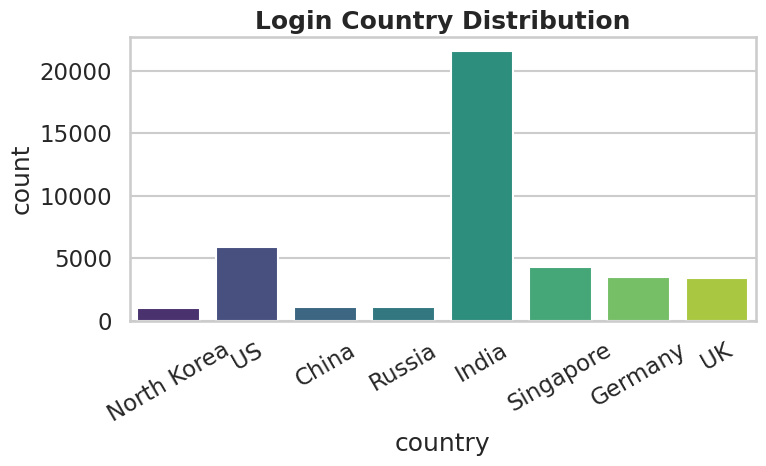

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("talk")

df = pd.read_csv("log_login_500users.csv")

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="country", palette="viridis")
plt.title("Login Country Distribution", fontsize=18, weight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

OS Usage per User (Normal vs Anomaly)

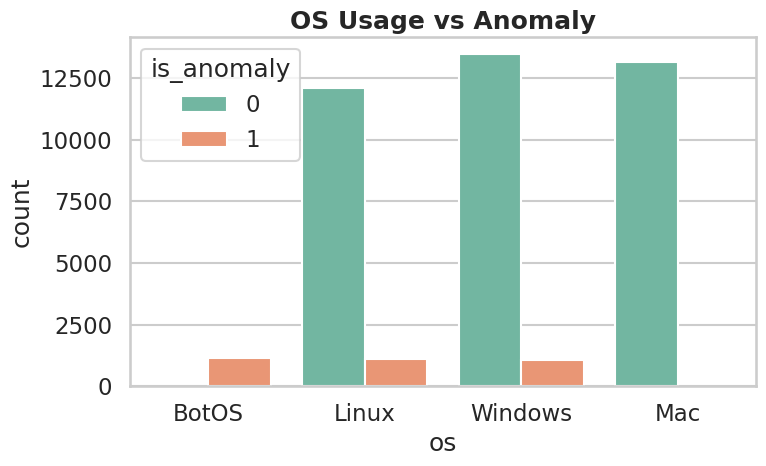

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="os", hue="is_anomaly", palette="Set2")
plt.title("OS Usage vs Anomaly", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

Mouse Velocity Distribution

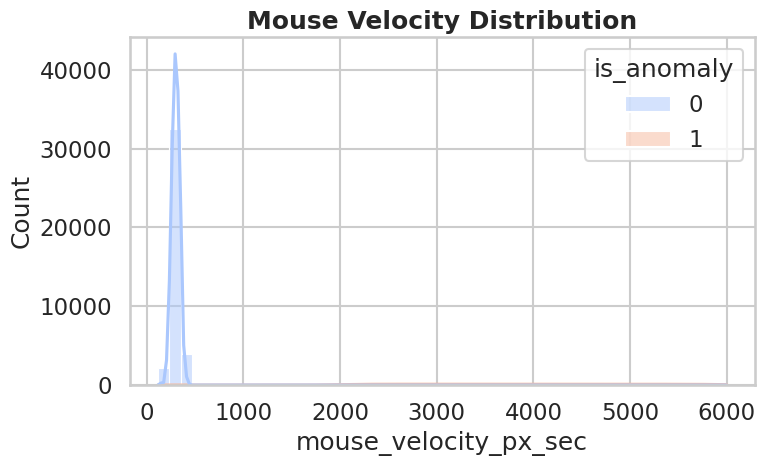

In [14]:
df_beh = pd.read_csv("log_behavior_500users.csv")
df_full = df.merge(df_beh, on=["login_id", "user_id"])

plt.figure(figsize=(8,5))
sns.histplot(data=df_full, x="mouse_velocity_px_sec",
             hue="is_anomaly", bins=50, kde=True, palette="coolwarm")
plt.title("Mouse Velocity Distribution", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

Correlation Heatmap (Behavioral)

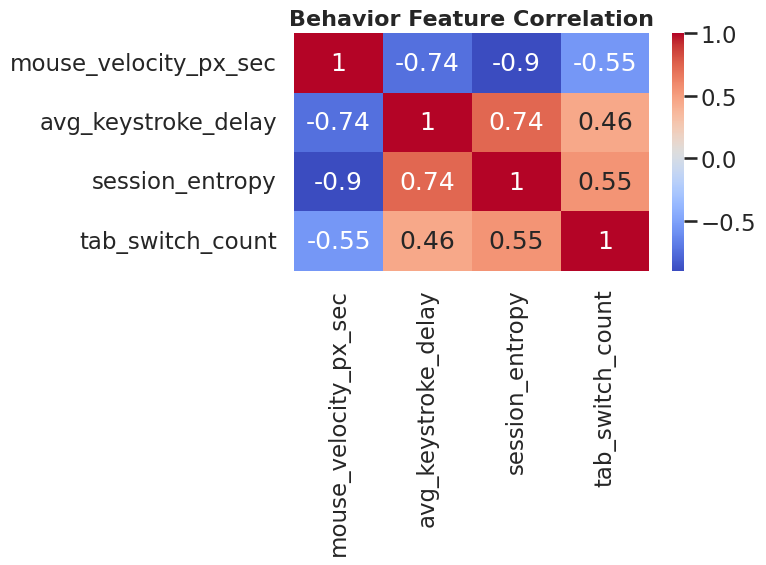

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(df_beh.iloc[:,2:].corr(), annot=True, cmap="coolwarm")
plt.title("Behavior Feature Correlation", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()